In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import pickle
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-18 21:26:05.325276


#### Functions

In [3]:
def age_tag(flt_age):
    if flt_age >= 60:
        return 1
    else:
        return 0

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

int_n_iterations = 100
int_n_early_stopping = 5

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import model

In [6]:
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
list_cols_model = [col.split('_binned')[0] for col in list_cols_model]
print(f'There are {len(list_cols_model)} features in the model')

There are 33 features in the model


#### Import data

In [7]:
# get cols to import
list_cols_id = [
    'accountid',
    'request_datetime',
    'bitdebtor',
    'subjectage__ln',
]
list_cols_import = list_cols_id + list_cols_model
# import
str_filename_tmp = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename_tmp}'
df = pd.read_parquet(
    str_uri,
    columns=list_cols_import,
)
# clean up subject age
df['subjectage__ln'] = df['subjectage__ln'].mask(df['subjectage__ln'] < 0, np.nan)
flt_mdn = df['subjectage__ln'].median()
print(f'Missing age imputed with {flt_mdn:0.2f}')
df['subjectage__ln'] = df['subjectage__ln'].fillna(flt_mdn)
# create tag
df['tag_age'] = df['subjectage__ln'].apply(age_tag)
# show
df

Missing age imputed with 42.00


,accountid,request_datetime,bitdebtor,subjectage__ln,rev326__tu,au20s__tu,linkt001__tu,miles_odometer__app,balmag01__tu,fltgrossmonthly__income_sum,...,per235__tu,co01s__tu,st20s__tu,fi36s__tu,fi25s__tu,in21s__tu,aut252__tu,flt_wtd_avg_open__tu_pmthx,s068b__tu,tag_age
37865,5514485,2022-10-15 02:35:52.2455863,1,48.0,NaN,4.0,2.0,44878.0,231.0,3976.280029,...,NaN,0.0,NaN,999.0,NaN,4.0,0.0,1.000000,NaN,0
37866,5514970,2022-10-15 02:36:32.6396499,1,32.0,NaN,52.0,6.0,26828.0,180.0,5720.000000,...,1095.0,0.0,58.0,18.0,1.0,1.0,1.0,0.831071,6.0,0
37869,5515245,2022-10-15 02:36:53.5525392,1,34.0,NaN,101.0,4.0,1456.0,164.0,4822.600098,...,NaN,0.0,141.0,1.0,0.0,29.0,0.0,0.637931,2.0,0
37870,5515340,2022-10-15 02:37:13.5377961,1,46.0,NaN,NaN,1.0,83463.0,267.0,4160.000000,...,246.0,1.0,NaN,13.0,NaN,18.0,NaN,NaN,0.0,0
37871,5515580,2022-10-15 02:37:34.1144830,0,32.0,NaN,116.0,0.0,24384.0,NaN,2357.330078,...,NaN,0.0,NaN,NaN,NaN,99.0,NaN,NaN,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,1,43.0,71.0,80.0,5.0,61431.0,313.0,6046.060000,...,NaN,5.0,183.0,1.0,NaN,5.0,0.0,NaN,4.0,0
94472,8420588,2024-11-26 06:16:16+00:00,1,41.0,0.0,79.0,3.0,27622.0,436.0,8085.730000,...,NaN,4.0,269.0,1.0,NaN,34.0,0.0,NaN,4.0,0
94426,8420665,2024-11-26 02:37:11+00:00,1,47.0,NaN,71.0,4.0,23845.0,NaN,3951.180000,...,NaN,0.0,NaN,1.0,NaN,42.0,NaN,0.136585,NaN,0
94456,8421889,2024-11-26 05:10:18+00:00,1,42.0,NaN,54.0,2.0,17.0,242.0,4116.670000,...,0.0,10.0,NaN,2.0,0.0,16.0,0.0,0.747619,7.0,0


#### Impute

In [8]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        df[key] = df[key].fillna(val)
    except KeyError:
        pass

100%|██████████| 988/988 [00:00<00:00, 10258.58it/s]


#### Get targets

In [9]:
str_filename = 'df.gzip'
str_local_path = f'../../disparate_targets/output/{str_filename}'
df_tmp = pd.read_parquet(str_local_path)
# show
df_tmp

,bigAccountId,bigDebtorId,bitDebtor,strNameFirst,strNameLast,strZipCode,max_proba_race,race,gender
index,,,,,,,,,
0,6476061,8090461,1,ONEAL,TOMETI,85024,NaN,None,male
1,6476062,8090462,1,ELI,BARKER,98499,0.872785,white,female
2,6476063,8090463,1,THERESA,LASTER-SAVOY,21208,NaN,None,female
3,6476064,8090464,1,JONATHON,MOORE,76302,0.967576,white,male
4,6476065,8090465,1,ELIZABETH,MARTINEZ,77396,0.971855,hispanic,female
...,...,...,...,...,...,...,...,...,...
3290835,7627122,9469597,1,MISTY,HARDING,97213,NaN,None,female
3290836,7627123,9469598,1,PEDRO,SAMA LOZADA,24012,NaN,None,male
3290837,7627124,9469599,1,MARY,WICKS,63146,NaN,None,female


#### Join

In [10]:
df = pd.merge(
    left=df,
    right=df_tmp,
    left_on=['accountid', 'bitdebtor'],
    right_on=['bigAccountId', 'bitDebtor'],
    how='inner',
)
del df_tmp
# show
df

,accountid,request_datetime,bitdebtor,subjectage__ln,rev326__tu,au20s__tu,linkt001__tu,miles_odometer__app,balmag01__tu,fltgrossmonthly__income_sum,...,tag_age,bigAccountId,bigDebtorId,bitDebtor,strNameFirst,strNameLast,strZipCode,max_proba_race,race,gender
0,5514485,2022-10-15 02:35:52.2455863,1,48.0,0.0,4.0,2.0,44878.0,231.0,3976.280029,...,0,5514485,6937315,1,JEFFREY,GRACE,22851,0.994012,white,male
1,5514970,2022-10-15 02:36:32.6396499,1,32.0,0.0,52.0,6.0,26828.0,180.0,5720.000000,...,0,5514970,6937905,1,JOSHUA,JENKINS,95973,0.652227,white,male
2,5515245,2022-10-15 02:36:53.5525392,1,34.0,0.0,101.0,4.0,1456.0,164.0,4822.600098,...,0,5515245,6938233,1,JEREMY,FARRAR,78727,0.967017,white,male
3,5515580,2022-10-15 02:37:34.1144830,0,32.0,0.0,116.0,0.0,24384.0,600.0,2357.330078,...,0,5515580,6938635,0,MARCUS,OTT,40741,0.898239,black,male
4,5515580,2022-10-15 02:37:34.1144830,1,33.0,0.0,1.0,1.0,24384.0,600.0,1924.000000,...,0,5515580,6938634,1,BRANDY,SPAULDING,40741,0.841417,white,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76006,8420084,2024-11-26 03:18:22+00:00,1,32.0,0.0,88.0,4.0,54467.0,302.0,3772.080000,...,0,8420084,10396391,1,CANDICE,ELLIOTT,45240,0.682949,white,female
76007,8420216,2024-11-26 04:59:34+00:00,1,71.0,29.0,131.0,0.0,63005.0,272.0,5122.830000,...,1,8420216,10396557,1,RAUL,MORENO,33016,0.999372,hispanic,male
76008,8420588,2024-11-26 06:16:16+00:00,1,41.0,0.0,79.0,3.0,27622.0,436.0,8085.730000,...,0,8420588,10397012,1,COURTNEY,GAYLOR,27597,0.889285,white,female
76009,8421889,2024-11-26 05:10:18+00:00,1,42.0,0.0,54.0,2.0,17.0,242.0,4116.670000,...,0,8421889,10398666,1,RYAN,LIMORAN,30052,NaN,None,male


#### Race

In [11]:
# make copy
df_tmp = df.copy()
# subset
df_tmp = df_tmp[df_tmp['max_proba_race'] >= 0.70].copy()

# make mapping dictionary for target
dict_map = {
    'white': 0,
    'black': 1,
    'hispanic': 2,
    'native': 3,
    'api': 4,
    'multiple': 5,
}
df_tmp['target'] = df_tmp['race'].map(dict_map)

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='MultiClass',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_race = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_race.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_race['rank'] = list(range(1, df_race.shape[0]+1))

# save
str_filename = 'df_race.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_race.to_csv(str_local_path, index=False)

# dictionary
dict_race = dict(zip(df_race['feature'], df_race['rank']))

# show
df_race

Learning rate set to 0.279907
0:	learn: 1.2543838	test: 1.2600428	best: 1.2600428 (0)	total: 89.5ms	remaining: 8.86s
10:	learn: 0.8193184	test: 0.8314095	best: 0.8314095 (10)	total: 441ms	remaining: 3.57s
20:	learn: 0.7981835	test: 0.8183050	best: 0.8183050 (20)	total: 802ms	remaining: 3.02s
30:	learn: 0.7910719	test: 0.8174349	best: 0.8174349 (30)	total: 1.11s	remaining: 2.48s
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.8172485841
bestIteration = 33

Shrink model to first 34 iterations.


,feature,importance,rank
26,st20s__tu,7.019479,1
5,fltgrossmonthly__income_sum,5.817248,2
27,fi36s__tu,5.723520,3
16,g002s__tu,5.253398,4
23,linka006__tu,5.211662,5
9,ENG-loan_to_value,5.035335,6
1,au20s__tu,4.726449,7
2,linkt001__tu,4.595619,8
10,trv10__tu,4.519289,9
14,jt20s__tu,4.201078,10


#### Gender

In [12]:
# make copy
df_tmp = df.copy()

# make mapping dictionary
dict_map = {
    'male': 0,
    'female': 1,
}
df_tmp['target'] = df_tmp['gender'].map(dict_map)

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_gender = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_gender.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_gender['rank'] = list(range(1, df_gender.shape[0]+1))

# save
str_filename = 'df_gender.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_gender.to_csv(str_local_path, index=False)

# dictionary
dict_gender = dict(zip(df_gender['feature'], df_gender['rank']))

# show
df_gender

Learning rate set to 0.234221
0:	test: 0.6734228	best: 0.6734228 (0)	total: 58.9ms	remaining: 5.83s
10:	test: 0.7072437	best: 0.7072437 (10)	total: 330ms	remaining: 2.67s
20:	test: 0.7103265	best: 0.7103265 (20)	total: 535ms	remaining: 2.01s
30:	test: 0.7112791	best: 0.7112791 (30)	total: 687ms	remaining: 1.53s
40:	test: 0.7123554	best: 0.7123554 (40)	total: 819ms	remaining: 1.18s
50:	test: 0.7134378	best: 0.7134378 (50)	total: 1.01s	remaining: 970ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.7137542524
bestIteration = 52

Shrink model to first 53 iterations.


,feature,importance,rank
26,st20s__tu,27.040571,1
5,fltgrossmonthly__income_sum,22.699313,2
8,rtl_trd__tu,13.018093,3
3,miles_odometer__app,4.117458,4
14,jt20s__tu,3.814888,5
12,cv15__tu,2.572308,6
29,in21s__tu,2.423421,7
20,linkf098__tu,1.888145,8
1,au20s__tu,1.880100,9
7,int_n_months_open__tu_pmthx,1.789313,10


#### Age

In [13]:
# make copy
df_tmp = df.copy()

# create target
df_tmp['target'] = df_tmp['tag_age']

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_age = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_age.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_age['rank'] = list(range(1, df_age.shape[0]+1))

# save
str_filename = 'df_age.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_age.to_csv(str_local_path, index=False)

# dictionary
dict_age = dict(zip(df_age['feature'], df_age['rank']))

# show
df_age

Learning rate set to 0.234221
0:	test: 0.5594966	best: 0.5594966 (0)	total: 20.9ms	remaining: 2.07s
10:	test: 0.7279551	best: 0.7279551 (10)	total: 266ms	remaining: 2.15s
20:	test: 0.7378798	best: 0.7378798 (20)	total: 407ms	remaining: 1.53s
30:	test: 0.7418656	best: 0.7418656 (30)	total: 570ms	remaining: 1.27s
40:	test: 0.7442590	best: 0.7446765 (37)	total: 810ms	remaining: 1.17s
50:	test: 0.7473295	best: 0.7473923 (49)	total: 971ms	remaining: 933ms
60:	test: 0.7482346	best: 0.7482346 (60)	total: 1.23s	remaining: 789ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.7482346102
bestIteration = 60

Shrink model to first 61 iterations.


,feature,importance,rank
26,st20s__tu,17.642496,1
2,linkt001__tu,10.643963,2
5,fltgrossmonthly__income_sum,10.539779,3
1,au20s__tu,9.699909,4
8,rtl_trd__tu,8.144309,5
14,jt20s__tu,6.468244,6
20,linkf098__tu,4.641157,7
29,in21s__tu,3.426569,8
4,balmag01__tu,2.866238,9
16,g002s__tu,2.494703,10


#### Map

In [14]:
df = df_race.copy()

# drop
df.drop('importance', axis=1, inplace=True)

# rename
dict_rename = {
    'rank': 'rank_race',
}
df.rename(columns=dict_rename, inplace=True)

# map age
df['rank_age'] = df['feature'].map(dict_age)

# map gender
df['rank_gender'] = df['feature'].map(dict_gender)

# sum
list_cols = [
    'rank_race',
    'rank_age',
    'rank_gender',
]
df['rank_mean'] = df[list_cols].mean(axis=1)

# sort
df.sort_values(by='rank_mean', ascending=True, inplace=True)

# show
df

,feature,rank_race,rank_age,rank_gender,rank_mean
26,st20s__tu,1,1,1,1.000000
5,fltgrossmonthly__income_sum,2,3,2,2.333333
1,au20s__tu,7,4,9,6.666667
14,jt20s__tu,10,6,5,7.000000
8,rtl_trd__tu,13,5,3,7.000000
9,ENG-loan_to_value,6,12,11,9.666667
23,linka006__tu,5,13,16,11.333333
2,linkt001__tu,8,2,25,11.666667
3,miles_odometer__app,20,11,4,11.666667
29,in21s__tu,22,8,7,12.333333


#### Get the output from sensitivity analysis

In [15]:
str_filename = 'df_sensitivity.csv'
str_local_path = f'../02_model/output/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
# rm binned
df_tmp['feature'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# show
#df_tmp

#### Join

In [16]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='feature',
    how='inner',
)
# show
#df

#### Get data dictionary for mapping description

In [17]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Map description

In [18]:
df['description'] = df['feature'].map(dict_map_descriptions)
# show
df

,feature,rank_race,rank_age,rank_gender,rank_mean,score,target,diff,description
0,st20s__tu,1,1,1,1.000000,0.648142,0.648235,-0.000093,Months since oldest student loan trade opened
1,fltgrossmonthly__income_sum,2,3,2,2.333333,0.647456,0.648235,-0.000779,NaN
2,au20s__tu,7,4,9,6.666667,0.647058,0.648235,-0.001176,Months since oldest auto trade opened
3,jt20s__tu,10,6,5,7.000000,0.647773,0.648235,-0.000461,Months since oldest joint trade opened
4,rtl_trd__tu,13,5,3,7.000000,0.646532,0.648235,-0.001703,Number of retail trades
5,ENG-loan_to_value,6,12,11,9.666667,0.641290,0.648235,-0.006945,NaN
6,linka006__tu,5,13,16,11.333333,0.647832,0.648235,-0.000403,Number of total inquiries in the last 3 years....
7,linkt001__tu,8,2,25,11.666667,0.645408,0.648235,-0.002826,Number of non-military addresses in last 7 years
8,miles_odometer__app,20,11,4,11.666667,0.645256,0.648235,-0.002979,NaN
9,in21s__tu,22,8,7,12.333333,0.646197,0.648235,-0.002038,Months since most recent installment trade opened


#### Save

In [19]:
str_filename = 'df.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

#### Plot

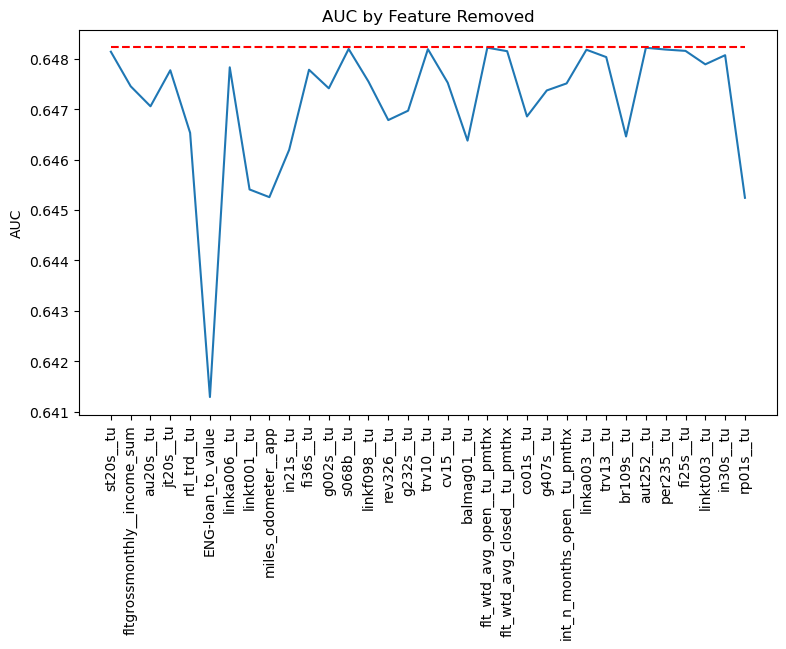

In [20]:
x = df['feature']
y = df['score']
z = df['target']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)

# save
str_filename = 'disparate_impact.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()